In [1]:
import pathlib
import numpy as np
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
from prepare import process_regressor, model_performance_metrics,draw_scatter
from data_prune_function import get_scores,get_data,prune_rd,return_model

test_size = 0.1

model = {}
for modelname in ['CB','XG','GB']:
    model[modelname] = return_model(modelname,random_state=1)

target = 'NO(%)'
df,X,y,X_train_val,X_test,y_train_val,y_test = get_data(target = target,random_state=6, test_size=test_size,standardized=False)
mad = (y - y.mean()).abs().mean()
std = y.std()
print('')
print('-----------------')
print(f'{target} {y.shape[0]} {mad:.3f} {std:.3f} ')
print('-----------------')
target = 'NO(%)'
a = 'CB'
b = 'XG'
c = 'GB'


-----------------
NO(%) 242 14.156 17.853 
-----------------


In [2]:
folder = f'{target}/{target}_{a}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_a = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{b}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_b = f'{folder}/all_dat.pkl'

folder = f'{target}/{target}_{c}_guiding_pruning'
pathlib.Path(f"./{folder}").mkdir(parents=True, exist_ok=True)
file_out_c = f'{folder}/all_dat.pkl'

In [3]:
maes_a, rmse_a, r2_a = get_scores(model[a], X_train_val, y_train_val, X_test, y_test)
maes_b, rmse_b, r2_b = get_scores(model[b], X_train_val, y_train_val, X_test, y_test)
maes_c, rmse_c, r2_c = get_scores(model[c], X_train_val, y_train_val, X_test, y_test)

Test scores: MAE=4.317, RMSE=5.460, R2=0.876
--- 0.9330019950866699 seconds ---

Test scores: MAE=5.052, RMSE=6.450, R2=0.827
--- 0.1753995418548584 seconds ---

Test scores: MAE=4.603, RMSE=5.919, R2=0.855
--- 0.11437344551086426 seconds ---



In [4]:
size_old_val_a, ids_a, test_scores_a, val_scores_a,test_fit_a,remove_a = prune_rd(
        model[a], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,
        threshold=maes_a / 2,train_size= 0.9, file_out=file_out_a)

Iteration 0:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.7790219783782959 seconds ---
修剪模型：
Test scores: maes=4.225, rmse=5.364, r2=0.881
--- 0.7479374408721924 seconds ---
Iteration 1:
丢弃训练词条数量 : 7 
本次循环中 old_val 数量: 5 (ratio = 0.023)
本次循环中新训练集大小，占比: 212  (ratio = 0.977)
--- 0.7170062065124512 seconds ---
修剪模型：
Test scores: maes=4.441, rmse=5.556, r2=0.872
Val scores: maes=1.631, rmse=2.176, r2=0.941
--- 0.750558614730835 seconds ---
Iteration 2:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 12 (ratio = 0.055)
本次循环中新训练集大小，占比: 205  (ratio = 0.945)
--- 0.703589916229248 seconds ---
修剪模型：
Test scores: maes=4.116, rmse=5.282, r2=0.884
Val scores: maes=1.630, rmse=2.263, r2=0.969
--- 0.8716857433319092 seconds ---
Iteration 3:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 16 (ratio = 0.074)
本次循环中新训练集大小，占比: 201  (ratio = 0.926)
--- 0.8340692520141602 seconds ---
修剪模型：
Test scores: maes=4.256, rmse=5.360, r2=0.881
Val scores: maes=1.523, rmse=2.009, r2=0.988
--- 0.768684

In [5]:
size_old_val_b, ids_b, test_scores_b, val_scores_b,test_fit_b,remove_b = prune_rd(
    model[b], X_train_val, y_train_val, X_test, y_test,max_iter=80,min_drop= 2,threshold=maes_b / 2,train_size= 0.9, file_out=file_out_b)

Iteration 0:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.09699511528015137 seconds ---
修剪模型：
Test scores: maes=4.982, rmse=6.286, r2=0.836
--- 0.0986030101776123 seconds ---
Iteration 1:
丢弃训练词条数量 : 8 
本次循环中 old_val 数量: 5 (ratio = 0.023)
本次循环中新训练集大小，占比: 212  (ratio = 0.977)
--- 0.09279990196228027 seconds ---
修剪模型：
Test scores: maes=4.948, rmse=6.240, r2=0.838
Val scores: maes=2.814, rmse=3.585, r2=0.868
--- 0.09461712837219238 seconds ---
Iteration 2:
丢弃训练词条数量 : 7 
本次循环中 old_val 数量: 13 (ratio = 0.060)
本次循环中新训练集大小，占比: 204  (ratio = 0.940)
--- 0.0999755859375 seconds ---
修剪模型：
Test scores: maes=4.520, rmse=5.828, r2=0.859
Val scores: maes=1.898, rmse=2.627, r2=0.973
--- 0.08964395523071289 seconds ---
Iteration 3:
丢弃训练词条数量 : 5 
本次循环中 old_val 数量: 20 (ratio = 0.092)
本次循环中新训练集大小，占比: 197  (ratio = 0.908)
--- 0.09090566635131836 seconds ---
修剪模型：
Test scores: maes=4.959, rmse=6.052, r2=0.848
Val scores: maes=2.987, rmse=3.669, r2=0.964
--- 0.09

In [6]:
size_old_val_c, ids_c, test_scores_c, val_scores_c,test_fit_c,remove_c = prune_rd(
        model[c], X_train_val, y_train_val, X_test, y_test,max_iter=80,
        min_drop= 2,threshold=maes_c / 2,train_size= 0.9, file_out=file_out_c)

Iteration 0:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 0 (ratio = 0.000)
本次循环中新训练集大小，占比: 217  (ratio = 1.000)
--- 0.11479520797729492 seconds ---
修剪模型：
Test scores: maes=4.190, rmse=5.482, r2=0.875
--- 0.11573576927185059 seconds ---
Iteration 1:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 4 (ratio = 0.018)
本次循环中新训练集大小，占比: 213  (ratio = 0.982)
--- 0.10598635673522949 seconds ---
修剪模型：
Test scores: maes=4.201, rmse=5.416, r2=0.878
Val scores: maes=2.492, rmse=3.089, r2=0.966
--- 0.11925387382507324 seconds ---
Iteration 2:
丢弃训练词条数量 : 2 
本次循环中 old_val 数量: 8 (ratio = 0.037)
本次循环中新训练集大小，占比: 209  (ratio = 0.963)
--- 0.10547566413879395 seconds ---
修剪模型：
Test scores: maes=4.361, rmse=5.673, r2=0.866
Val scores: maes=1.271, rmse=1.721, r2=0.989
--- 0.1097724437713623 seconds ---
Iteration 3:
丢弃训练词条数量 : 4 
本次循环中 old_val 数量: 10 (ratio = 0.046)
本次循环中新训练集大小，占比: 207  (ratio = 0.954)
--- 0.09969162940979004 seconds ---
修剪模型：
Test scores: maes=3.970, rmse=5.049, r2=0.894
Val scores: maes=1.572, rmse=2.033, r2=0.982
--- 0

In [7]:
from prepare import get_mse_rmse_mae_mape_smape_r2
import os
from matplotlib import pyplot as plt
import seaborn as sns
from matplotlib.ticker import MultipleLocator

def draw_scatter_1(train_true, train_pred, val_true, val_pred,
                   test_true, test_pred, title,
                   test_lower=None, test_upper=None,
                   actual_text='actual', pred_text='prediction',
                   save=False):
    """
    绘制三组数据的散点图（训练集、验证集、测试集）
    仅在测试集上添加误差区间和误差棒
    """

    # 统一字体设置
    plt.rcParams['font.family'] = 'Times New Roman'

    # 转成一维数组，避免 pandas / ndarray 混用出错
    train_true = np.asarray(train_true).ravel()
    train_pred = np.asarray(train_pred).ravel()
    val_true = np.asarray(val_true).ravel()
    val_pred = np.asarray(val_pred).ravel()
    test_true = np.asarray(test_true).ravel()
    test_pred = np.asarray(test_pred).ravel()

    if test_lower is not None:
        test_lower = np.asarray(test_lower).ravel()
    if test_upper is not None:
        test_upper = np.asarray(test_upper).ravel()

    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 8))

    # 定义字体样式
    font_common = {
        'family': 'Times New Roman',
        'color': '#2F4F4F',
        'weight': 'bold',
        'size': 18
    }
    legend_font = {'family': 'Times New Roman', 'weight': 'bold', 'size': 15}

    # ===== 先画训练集、验证集回归散点图（基础内容不变）=====
    sns.regplot(x=train_true, y=train_pred,
                color="dodgerblue", label='train',
                scatter_kws={'alpha': 0.5, 's': 18},
                ax=ax)

    sns.regplot(x=val_true, y=val_pred,
                color="orange", label="val",
                scatter_kws={'alpha': 0.5, 's': 10},
                ax=ax)

    sns.regplot(x=test_true, y=test_pred,
                color='#FF69B4', label='test',
                scatter_kws={'alpha': 0.8, 's': 30},
                ax=ax)

    # ===== 只对测试集添加误差区间和误差棒 =====
    if test_lower is not None and test_upper is not None:
        # 按真实值排序，保证阴影区间平滑
        sorted_idx = np.argsort(test_true)
        test_true_sorted = test_true[sorted_idx]
        test_pred_sorted = test_pred[sorted_idx]
        lower_sorted = test_lower[sorted_idx]
        upper_sorted = test_upper[sorted_idx]

        # 计算误差棒上下长度
        yerr_lower = np.maximum(test_pred_sorted - lower_sorted, 0)
        yerr_upper = np.maximum(upper_sorted - test_pred_sorted, 0)

        # 置信区间阴影
        ax.fill_between(
            test_true_sorted,
            lower_sorted,
            upper_sorted,
            color='lightgray',
            alpha=0.5,
            label='95% Confidence Interval',
            zorder=1
        )

        # 误差棒
        ax.errorbar(
            test_true_sorted,
            test_pred_sorted,
            yerr=[yerr_lower, yerr_upper],
            fmt='o',
            markersize=4,
            color='#FF69B4',
            ecolor='gray',
            elinewidth=1,
            capsize=3,
            alpha=0.7,
            zorder=2
        )

    # ===== 坐标轴标签和范围 =====
    ax.set_xlabel(actual_text, fontdict=font_common, weight='bold')
    ax.set_ylabel(pred_text, fontdict=font_common, weight='bold')
    ax.set_xlim(15, 95)
    ax.set_ylim(15, 95)

    # 图例
    ax.legend(loc="lower right", markerscale=1.5, prop=legend_font,
              frameon=True)

    # 刻度
    ax.tick_params(axis='both', which='major', direction='out',
                   width=2, labelsize=16,
                   bottom=True, top=False, left=True, right=False)
    ax.tick_params(axis='both', which='minor', direction='out',
                   bottom=True, top=False, left=True, right=False)
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontsize(16)      # 放大字体
        label.set_fontweight('bold')  # 加粗
        label.set_family('Times New Roman')
    ax.xaxis.set_major_locator(MultipleLocator(10))
    ax.yaxis.set_major_locator(MultipleLocator(10))
    ax.xaxis.set_minor_locator(MultipleLocator(10))
    ax.yaxis.set_minor_locator(MultipleLocator(10))

    # 背景和边框
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_linewidth(3)
        spine.set_edgecolor('black')

    # 网格
    ax.grid(True, axis='both', linestyle='--',
            linewidth=0.5, color='gray', alpha=0.6)

    # ===== 统计信息 =====
    _, _, _, _, _, train_r2 = get_mse_rmse_mae_mape_smape_r2(
        train_true / 100, train_pred / 100
    )
    _, _, _, _, _, val_r2 = get_mse_rmse_mae_mape_smape_r2(
        val_true / 100, val_pred / 100
    )
    _, _, _, _, _, test_r2 = get_mse_rmse_mae_mape_smape_r2(
        test_true / 100, test_pred / 100
    )

    ax.text(20, 86, f"Train R² = {train_r2:.3f}", **font_common)
    ax.text(20, 80, f"val   R² = {val_r2:.3f}", **font_common)
    ax.text(20, 74, f"test  R² = {test_r2:.3f}", **font_common)

    # 标题
    ax.text(50, 90, title, **font_common, horizontalalignment="center")

    # 保存
    if save:
        out_put = 'prune2'
        if not os.path.exists(out_put):
            os.makedirs(out_put)
        output_path = os.path.join(out_put, f'{title}.jpg')
        plt.savefig(output_path, format="jpg", dpi=600,
                    bbox_inches="tight",
                    pil_kwargs={'quality': 95})
        print(f"测试图已保存：{output_path}")

    plt.tight_layout()
    plt.show()

In [8]:
a_test_70 = list(set(ids_a['train_val']) - set(remove_a[23]))
b_test_70 = list(set(ids_b['train_val']) - set(remove_b[21]))
c_test_70 = list(set(ids_c['train_val']) - set(remove_c[21]))

Cat Train 70% mse: 0.00010 | rmse: 0.01007 | mae: 0.00796 | mape: 2.09107 | smape: 2.07091 | r2: 0.99716

Cat val 30% mse: 0.00126 | rmse: 0.03547 | mae: 0.02868 | mape: 7.43792 | smape: 7.42454 | r2: 0.95043

Cat test mse: 0.00264 | rmse: 0.05136 | mae: 0.04330 | mape: 10.86536 | smape: 10.62763 | r2: 0.89055

测试图已保存：prune2\Catboost prune 70%.jpg


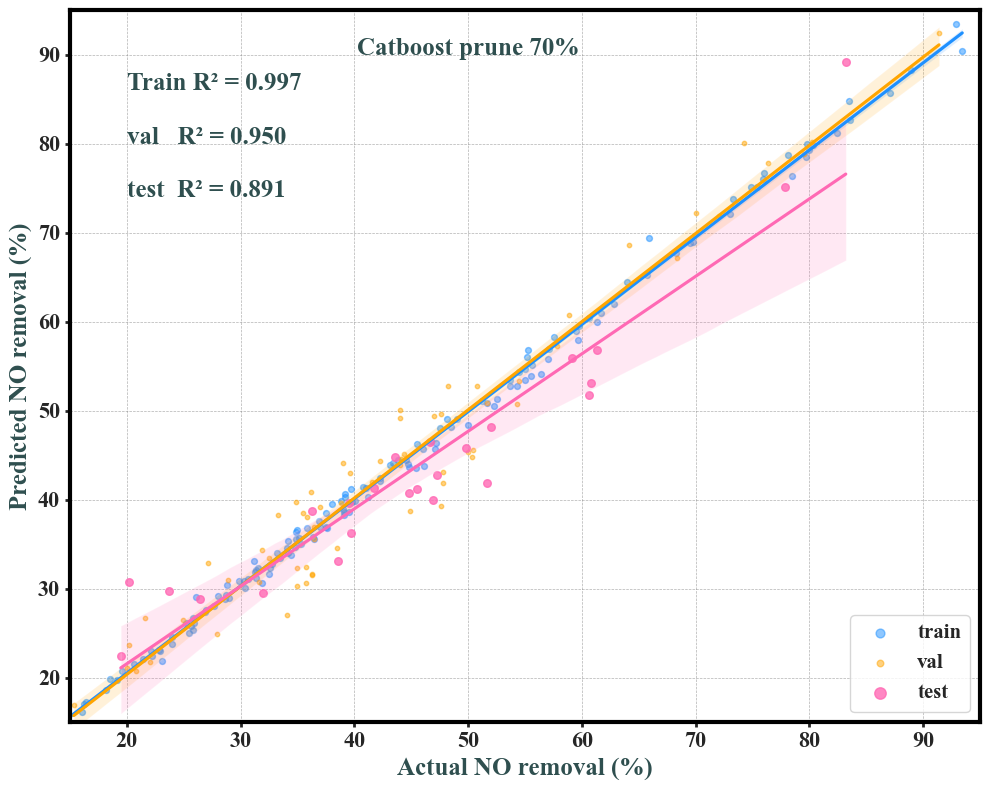

In [9]:
df_a = df.loc[remove_a[23]]
X_train_val = df_a.drop(columns=['NO(%)'])
y_train_val = df_a['NO(%)']
df_a_val = df.loc[a_test_70]
X_val = df_a_val.drop(columns=['NO(%)'])
y_val = df_a_val['NO(%)']
train_pred, val_pred = process_regressor(model[a],X_train_val,X_val,y_train_val,y_val,cv=False)
_,test_pred = process_regressor(model[a],X_train_val,X_test,y_train_val,y_test,cv=False)
model_performance_metrics('Cat Train 70%', y_train_val, train_pred)
model_performance_metrics('Cat val 30%', y_val, val_pred)
model_performance_metrics('Cat test', y_test, test_pred)
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "Catboost prune 70%", actual_text='Actual NO removal (%)',test_lower=None,test_upper=None,pred_text='Predicted NO removal (%)',save=True)

cv train R2: -0.305 (+/- 0.508) 

cv train R2: -0.305 (+/- 0.508) 

XGB Train 70% mse: 0.00045 | rmse: 0.02115 | mae: 0.01694 | mape: 4.47333 | smape: 4.39596 | r2: 0.98704

XGB val 30% mse: 0.00183 | rmse: 0.04276 | mae: 0.03494 | mape: 9.22026 | smape: 9.02751 | r2: 0.93361

XGB test mse: 0.00401 | rmse: 0.06336 | mae: 0.04941 | mape: 13.75236 | smape: 12.66240 | r2: 0.83344

测试图已保存：prune2\XGBboost prune 70%.jpg


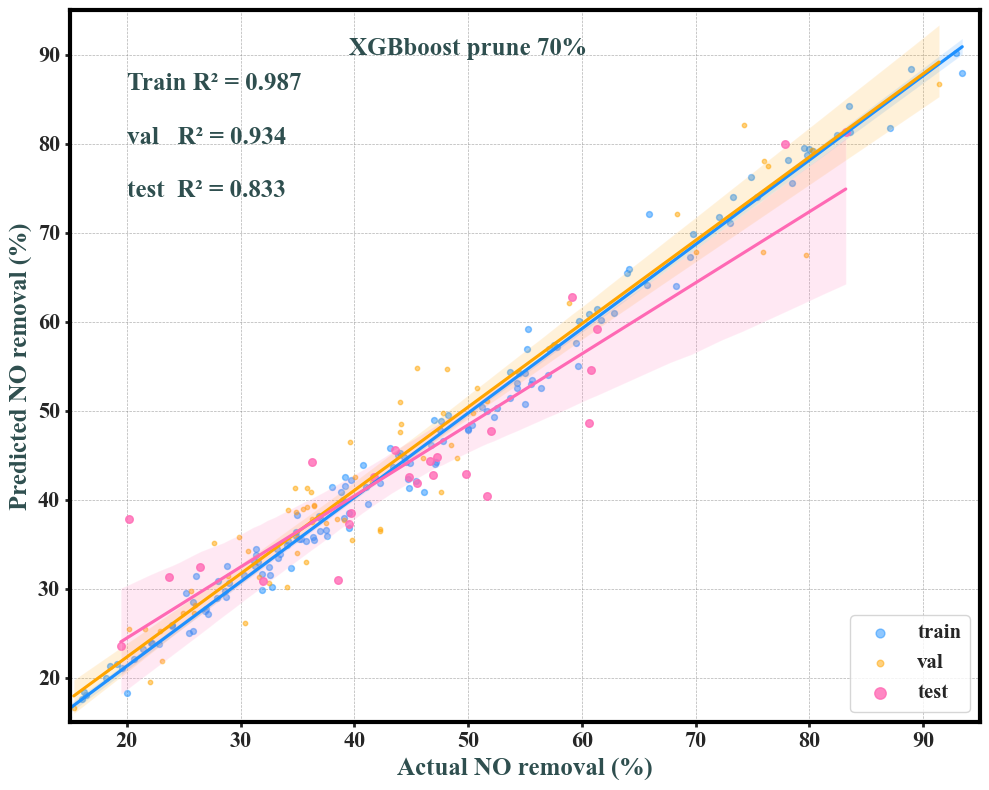

In [10]:
df_b = df.loc[remove_b[21]]
X_train_val = df_b.drop(columns=['NO(%)'])
y_train_val = df_b['NO(%)']
df_b_val = df.loc[b_test_70]
X_val = df_b_val.drop(columns=['NO(%)'])
y_val = df_b_val['NO(%)']
train_pred, val_pred = process_regressor(model[b],X_train_val,X_val,y_train_val,y_val)
_,test_pred = process_regressor(model[b],X_train_val,X_test,y_train_val,y_test)
model_performance_metrics('XGB Train 70%', y_train_val, train_pred)
model_performance_metrics('XGB val 30%', y_val, val_pred)
model_performance_metrics('XGB test', y_test, test_pred)
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "XGBboost prune 70%", actual_text='Actual NO removal (%)',test_lower=None,test_upper=None,pred_text='Predicted NO removal (%)',save=True)

cv train R2: -0.142 (+/- 0.264) 

cv train R2: -0.142 (+/- 0.264) 

GradientBoost Train 70% mse: 0.00001 | rmse: 0.00271 | mae: 0.00219 | mape: 0.56460 | smape: 0.56334 | r2: 0.99979

GradientBoost val 30% mse: 0.00170 | rmse: 0.04121 | mae: 0.03356 | mape: 9.67715 | smape: 9.12379 | r2: 0.93059

GradientBoost test mse: 0.00317 | rmse: 0.05630 | mae: 0.04598 | mape: 12.47890 | smape: 11.70650 | r2: 0.86846

测试图已保存：prune2\GradientBoost prune 70%.jpg


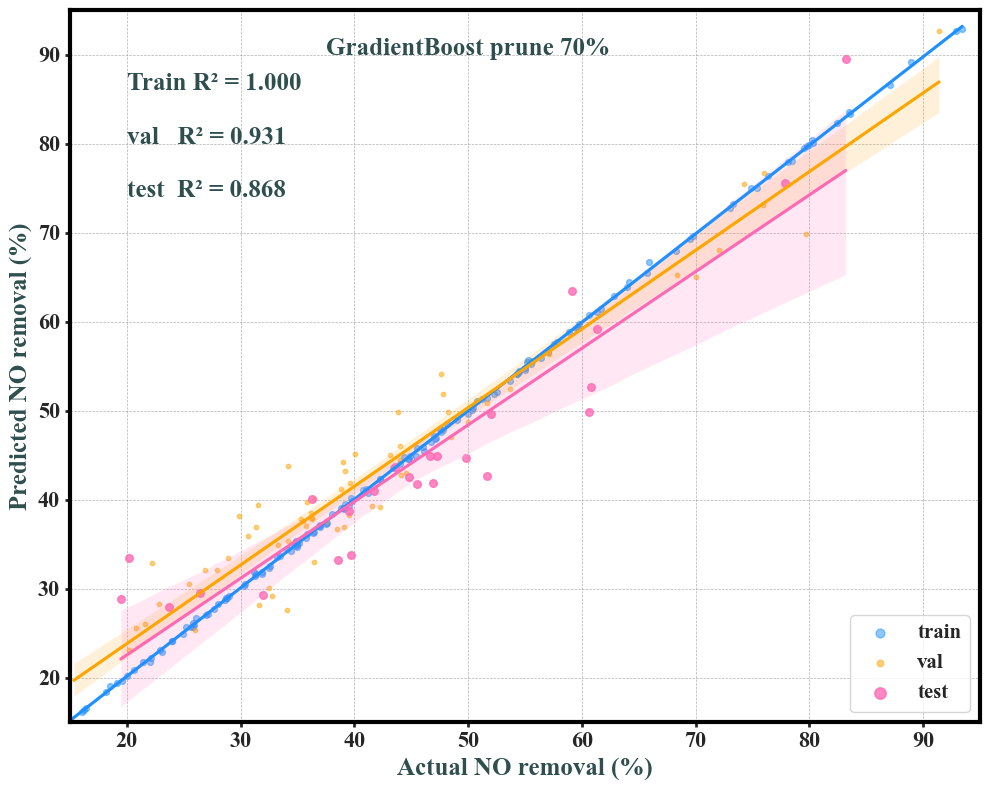

In [11]:
df_c = df.loc[remove_c[21]]
X_train_val = df_c.drop(columns=['NO(%)'])
y_train_val = df_c['NO(%)']
df_c_val = df.loc[c_test_70]
X_val = df_c_val.drop(columns=['NO(%)'])
y_val = df_c_val['NO(%)']
train_pred, val_pred = process_regressor(model[c],X_train_val,X_val,y_train_val,y_val,cv=True)
_,test_pred = process_regressor(model[c],X_train_val,X_test,y_train_val,y_test,cv=True)
model_performance_metrics('GradientBoost Train 70%', y_train_val, train_pred)
model_performance_metrics('GradientBoost val 30%', y_val, val_pred)
model_performance_metrics('GradientBoost test', y_test, test_pred)
draw_scatter_1(y_train_val, train_pred, y_val,val_pred,y_test, test_pred, "GradientBoost prune 70%", actual_text='Actual NO removal (%)',test_lower=None,test_upper=None,pred_text='Predicted NO removal (%)',save=True)